### Practical Lab 3 - Vanilla CNN and Fine-Tune VGG16 - for Dogs and Cats Classification

## Name: Vishal Thakkar (8974700) - Section 1


In [1]:
import os
import shutil
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve
import pathlib
import numpy as np
import random
import keras
from tensorflow.keras import layers



In [2]:
data_folder= pathlib.Path('../data/dog_cat_dataset')

The dataset is a small subset of the Dogs vs. Cats dataset on Kaggle, which is intended for tasks involving the categorization of binary images. It is divided into two classes: dogs and cats, and includes 2000 training images, 1000 validation images, and 2000 test photographs. For consistency, images are reduced to 180x180 pixels, and distinct folders are used for testing, validation, and training to make model building and assessment easier.

### Training a CNN for Image Classification Task

In [3]:
from tensorflow.keras.utils import image_dataset_from_directory

train_dataset = image_dataset_from_directory(
    data_folder / "train",
    image_size=(180, 180),
    batch_size=32)
validation_dataset = image_dataset_from_directory(
    data_folder / "validation",
    image_size=(180, 180),
    batch_size=32)
test_dataset = image_dataset_from_directory(
    data_folder / "test",
    image_size=(180, 180),
    batch_size=32)

Found 2000 files belonging to 2 classes.
Found 1000 files belonging to 2 classes.
Found 2000 files belonging to 2 classes.


### Defining the model

In [4]:
inputs = keras.Input(shape=(180, 180, 3))
x = layers.Rescaling(1./255)(inputs)
x = layers.Conv2D(filters=32, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=64, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=128, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.MaxPooling2D(pool_size=2)(x)
x = layers.Conv2D(filters=256, kernel_size=3, activation="relu")(x)
x = layers.Flatten()(x)
outputs = layers.Dense(1, activation="sigmoid")(x)
model = keras.Model(inputs=inputs, outputs=outputs)

In [5]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 991,041 (3.78 MB)

 Trainable params: 991,041 (3.78 MB)

 Non-trainable params: 0 (0.00 B)

2. EDA: Explore the data with relevant graphs, statistics and insights (5 points)

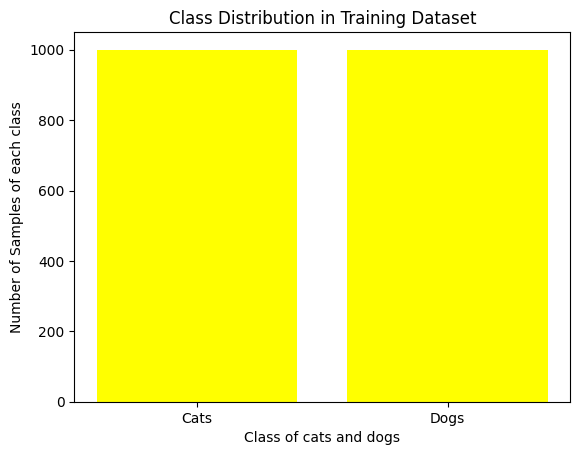

Class Distribution in Training Dataset: {'Cats': 1000, 'Dogs': 1000}


In [9]:
class_counts = {"Cats": 0, "Dogs": 0}

for _, labels in train_dataset:
    class_counts["Cats"] += np.sum(labels.numpy() == 0)
    class_counts["Dogs"] += np.sum(labels.numpy() == 1)

plt.bar(class_counts.keys(), class_counts.values(), color='yellow')
plt.title("Class Distribution in Training Dataset")
plt.xlabel("Class of cats and dogs")
plt.ylabel("Number of Samples of each class")
plt.show()

print(f"Class Distribution in Training Dataset: {class_counts}")

3. Train two networks 

## CNN

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Epoch 1/20


c:\Users\Vishal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\Vishal\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 256ms/step - accuracy: 0.5113 - loss: 0.7077 - val_accuracy: 0.5040 - val_loss: 0.6935
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 16s 257ms/step - accuracy: 0.5404 - loss: 0.6837 - val_accuracy: 0.6870 - val_loss: 0.6132
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 307ms/step - accuracy: 0.6913 - loss: 0.5896 - val_accuracy: 0.6720 - val_loss: 0.5938
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 287ms/step - accuracy: 0.7193 - loss: 0.5501 - val_accuracy: 0.6720 - val_loss: 0.6071
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 316ms/step - accuracy: 0.7479 - loss: 0.5089 - val_accuracy: 0.7430 - val_loss: 0.5508
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 21s 328ms/step - accuracy: 0.8217 - loss: 0.4005 - val_accuracy: 0.7320 - val_loss: 0.6036
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 20s 317ms/step - accuracy: 0.8421 - loss: 0.3458 - val_accuracy: 0.7240 - val_loss: 0.6351
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 18s 285ms/step - accuracy: 0.8835 - loss: 0.2734 - val_accuracy: 0.745

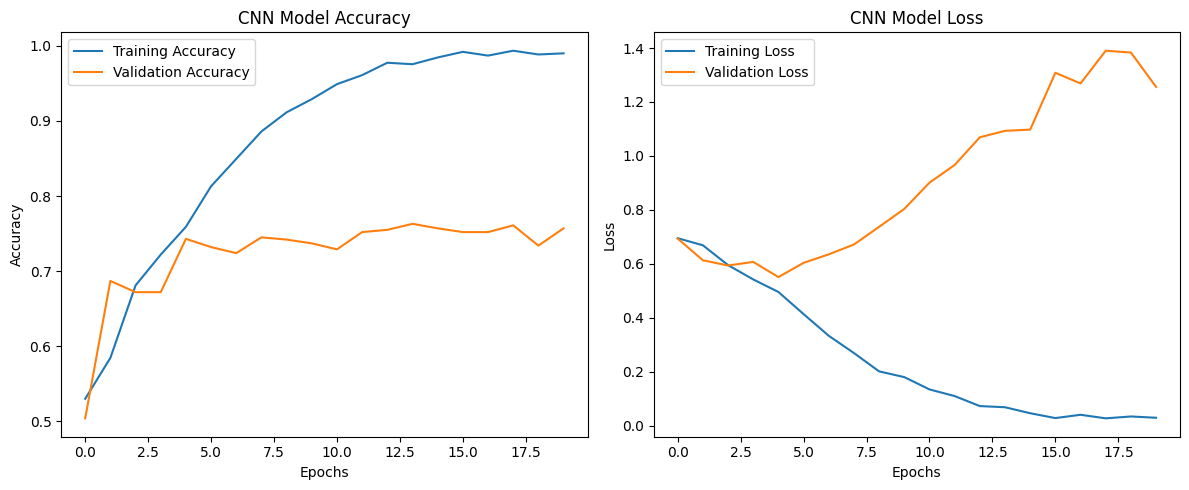

In [11]:
import pathlib
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Paths for dataset
data_folder = pathlib.Path('../data/dog_cat_dataset')
train_dir = data_folder / 'train'
validation_dir = data_folder / 'validation'

# Image Data Generators
train_datagen = ImageDataGenerator(rescale=1.0/255)
validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=32, class_mode='binary')

validation_generator = validation_datagen.flow_from_directory(
    validation_dir, target_size=(150, 150), batch_size=32, class_mode='binary')

# Define the CNN model
model_cnn = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(150, 150, 3)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

# Compile the model
model_cnn.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
checkpoint_cnn = ModelCheckpoint('cnn_best_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

# Train the model for 20 epochs
history_cnn = model_cnn.fit(
    train_generator,
    epochs=20,  # Set to 20 epochs
    validation_data=validation_generator,
    callbacks=[checkpoint_cnn]  # Only save the best model
)

# Plot training history for accuracy and loss
plt.figure(figsize=(8, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_cnn.history['accuracy'], label='Training Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.title('CNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_cnn.history['loss'], label='Training Loss')
plt.plot(history_cnn.history['val_loss'], label='Validation Loss')
plt.title('CNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()


# Fine-Tune VGG16

Found 2000 images belonging to 2 classes.
Found 1000 images belonging to 2 classes.
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 118s 2s/step - accuracy: 0.5931 - loss: 0.7490 - val_accuracy: 0.8730 - val_loss: 0.3851
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 127s 2s/step - accuracy: 0.8117 - loss: 0.4297 - val_accuracy: 0.8880 - val_loss: 0.2938
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 130s 2s/step - accuracy: 0.8708 - loss: 0.3021 - val_accuracy: 0.8660 - val_loss: 0.3006
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 129s 2s/step - accuracy: 0.8862 - loss: 0.2877 - val_accuracy: 0.8980 - val_loss: 0.2470
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 126s 2s/step - accuracy: 0.9076 - loss: 0.2502 - val_accuracy: 0.9090 - val_loss: 0.2422
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.9070 - loss: 0.2304 - val_accuracy: 0.8960 - val_loss: 0.2610
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 125s 2s/step - accuracy: 0.9281 - loss: 0.1917 - val_accuracy: 0.9010 - val_loss: 0.2495
Epoch 8/20
63/63 ━━━━━━━━━━

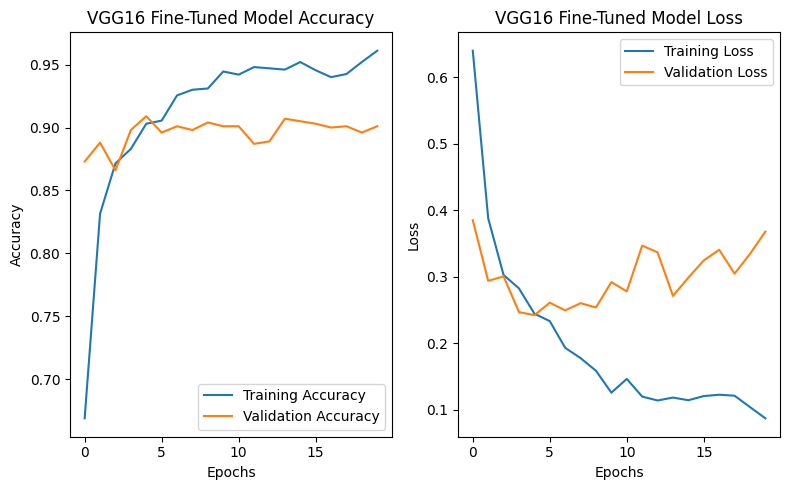

In [12]:
import pathlib
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

# Paths for dataset
data_folder = pathlib.Path('../data/dog_cat_dataset')
train_dir = data_folder / 'train'
validation_dir = data_folder / 'validation'

# Image Data Generators
train_datagen = ImageDataGenerator(rescale=1.0/255)
validation_datagen = ImageDataGenerator(rescale=1.0/255)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(150, 150), batch_size=32, class_mode='binary')

validation_generator = validation_datagen.flow_from_directory(
    validation_dir, target_size=(150, 150), batch_size=32, class_mode='binary')

# Load VGG16 Pre-Trained Model
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(150, 150, 3))
base_model.trainable = False  # Freeze the convolutional base

# Add Custom Layers
x = Flatten()(base_model.output)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

model_vgg16 = Model(inputs=base_model.input, outputs=output)

# Compile the model
model_vgg16.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Callbacks
checkpoint_vgg16 = ModelCheckpoint('vgg16_best_model.keras', save_best_only=True, monitor='val_accuracy', mode='max')

# Train the model
history_vgg16 = model_vgg16.fit(
    train_generator,
    epochs=20,  # Set to 20 epochs
    validation_data=validation_generator,
    callbacks=[checkpoint_vgg16]
)

# Plot training history for accuracy and loss
plt.figure(figsize=(8, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history_vgg16.history['accuracy'], label='Training Accuracy')
plt.plot(history_vgg16.history['val_accuracy'], label='Validation Accuracy')
plt.title('VGG16 Fine-Tuned Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history_vgg16.history['loss'], label='Training Loss')
plt.plot(history_vgg16.history['val_loss'], label='Validation Loss')
plt.title('VGG16 Fine-Tuned Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Show the plots
plt.tight_layout()
plt.show()


These graphs depict the performance of the fine-tuned VGG16 model over 20 epochs.

These graphs highlight the effectiveness of transfer learning and fine-tuning using the VGG16 architecture for improved performance and generalization on the validation data.


## 4. Explore the relative performance of the models (make sure to load the best version of each model)

1. accuracy

2. confusion metric

3. precision, recall, F1-score,
    
4. precision-recall curve.

5. Explore specific examples in which the model failed to predict correctly.


Found 2000 images belonging to 2 classes.
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 66ms/step
63/63 ━━━━━━━━━━━━━━━━━━━━ 69s 1s/step
Performance Metrics for CNN Model:
Accuracy: 0.7395
Confusion Matrix:
[[815 185]
 [336 664]]
Precision: 0.7821
Recall: 0.6640
F1-Score: 0.7182


Performance Metrics for VGG16 Model:
Accuracy: 0.8775
Confusion Matrix:
[[900 100]
 [145 855]]
Precision: 0.8953
Recall: 0.8550
F1-Score: 0.8747




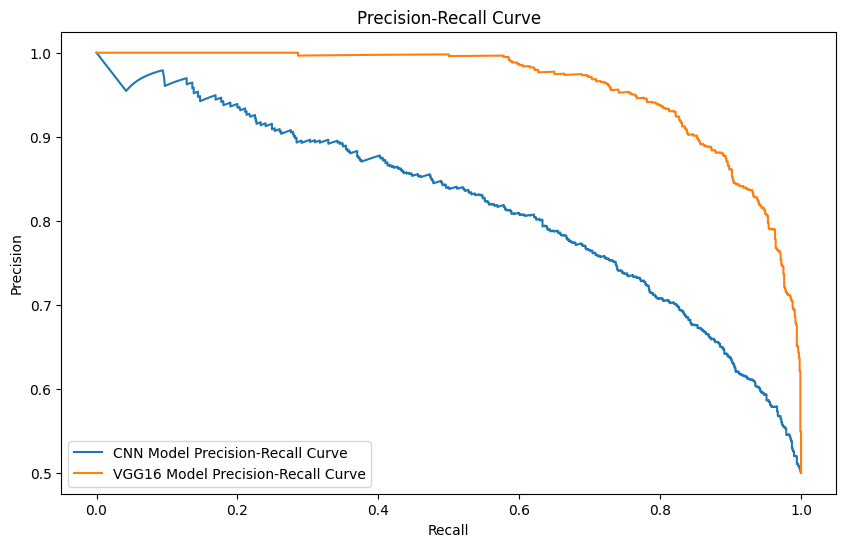


521 Misclassified Examples for CNN Model:



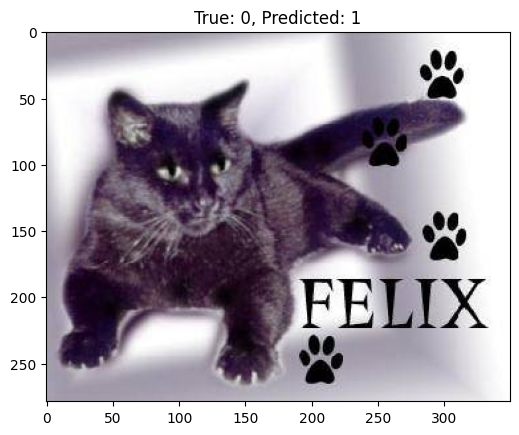

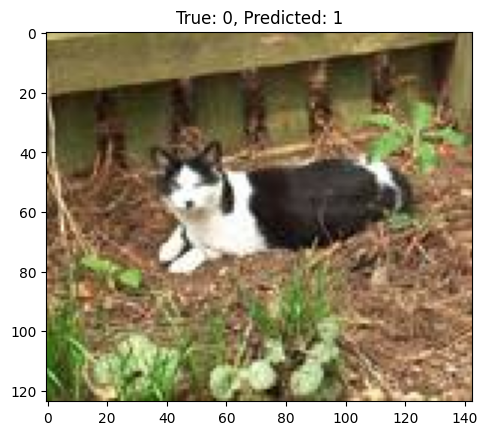

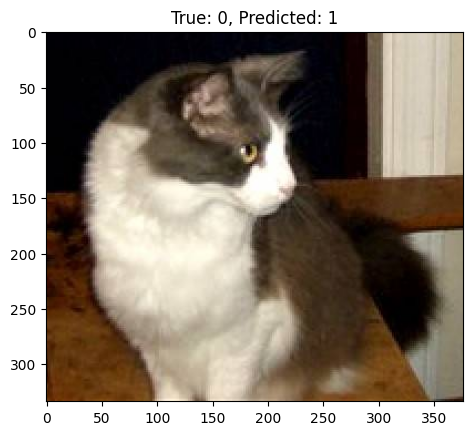

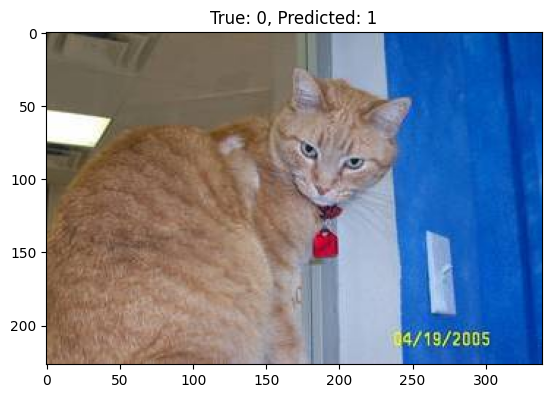

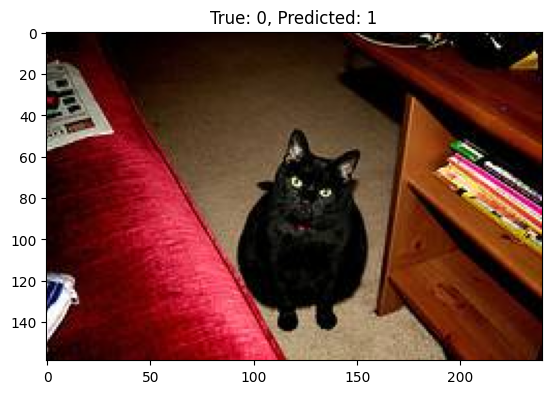


245 Misclassified Examples for VGG16 Model:



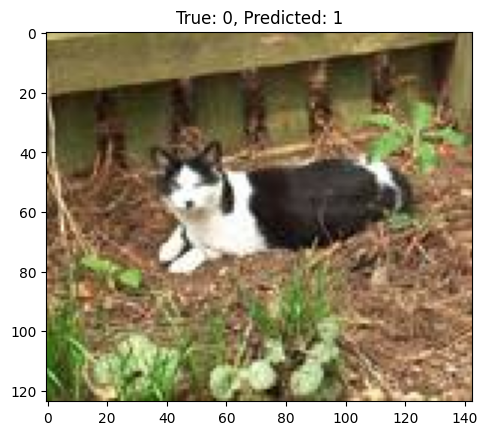

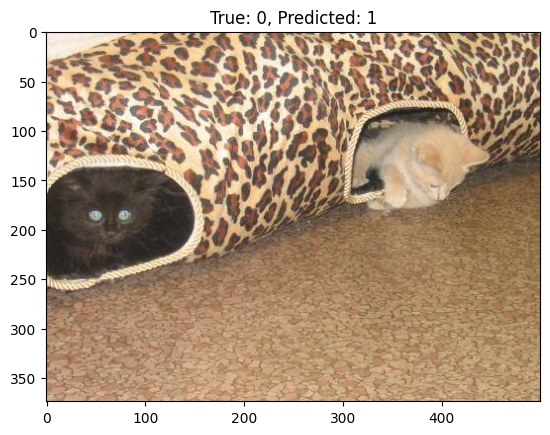

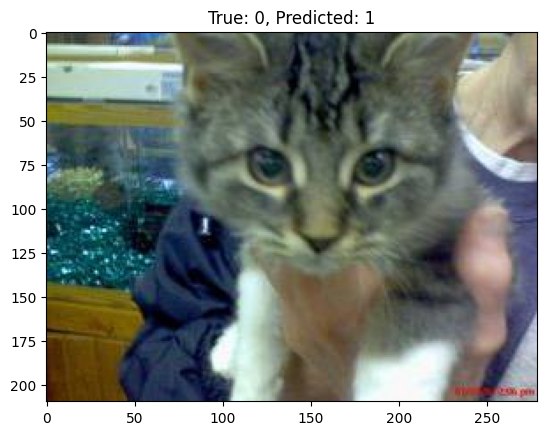

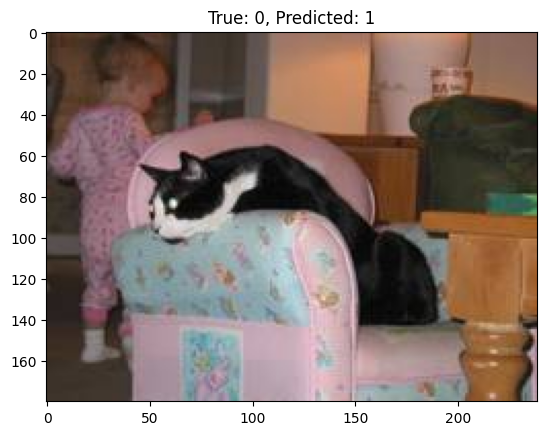

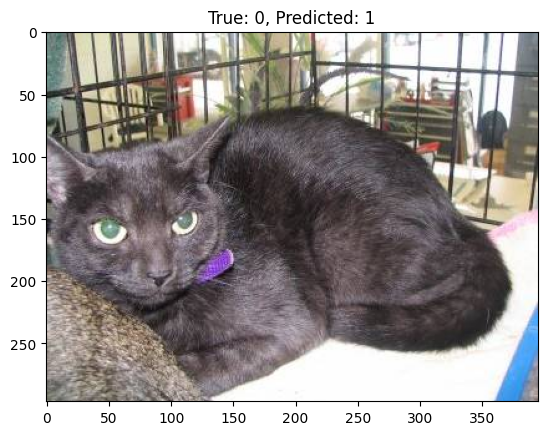

In [13]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, f1_score, precision_score, recall_score
import matplotlib.pyplot as plt
import tensorflow as tf

# Load the best saved models
cnn_model = tf.keras.models.load_model('cnn_best_model.keras')
vgg16_model = tf.keras.models.load_model('vgg16_best_model.keras')

# Prepare the test generator
test_datagen = ImageDataGenerator(rescale=1.0/255)
test_generator = test_datagen.flow_from_directory(
    data_folder / 'test',  # Assuming a 'test' folder exists
    target_size=(150, 150),
    batch_size=32,
    class_mode='binary',
    shuffle=False  # Important to maintain the order of predictions
)

# Function to evaluate a model
def evaluate_model(model, generator):
    # Get predictions and true labels
    probabilities = model.predict(generator)
    predictions = (probabilities > 0.5).astype(int).flatten()
    true_labels = generator.classes

    # Accuracy
    accuracy = np.mean(predictions == true_labels)

    # Confusion Matrix
    cm = confusion_matrix(true_labels, predictions)

    # Precision, Recall, F1-score
    precision = precision_score(true_labels, predictions)
    recall = recall_score(true_labels, predictions)
    f1 = f1_score(true_labels, predictions)

    # Precision-Recall Curve
    precision_vals, recall_vals, _ = precision_recall_curve(true_labels, probabilities)

    return accuracy, cm, precision, recall, f1, precision_vals, recall_vals, true_labels, predictions

# Evaluate CNN model
cnn_metrics = evaluate_model(cnn_model, test_generator)
vgg16_metrics = evaluate_model(vgg16_model, test_generator)

# Print Results
def print_results(model_name, metrics):
    accuracy, cm, precision, recall, f1, _, _, _, _ = metrics
    print(f"Performance Metrics for {model_name}:")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Confusion Matrix:\n{cm}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print("\n")

print_results("CNN Model", cnn_metrics)
print_results("VGG16 Model", vgg16_metrics)

# Plot Precision-Recall Curve
def plot_precision_recall_curve(model_name, precision_vals, recall_vals):
    plt.plot(recall_vals, precision_vals, label=f'{model_name} Precision-Recall Curve')
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve')
    plt.legend()

plt.figure(figsize=(10, 6))
plot_precision_recall_curve("CNN Model", cnn_metrics[5], cnn_metrics[6])
plot_precision_recall_curve("VGG16 Model", vgg16_metrics[5], vgg16_metrics[6])
plt.show()

# Explore Misclassified Examples
def explore_failures(model_name, generator, true_labels, predictions):
    misclassified_indices = np.where(predictions != true_labels)[0]
    print(f"\n{len(misclassified_indices)} Misclassified Examples for {model_name}:\n")

    # Display first 5 misclassified examples
    for i in misclassified_indices[:5]:
        image_path = generator.filepaths[i]
        true_class = generator.class_indices
        plt.imshow(plt.imread(image_path))
        plt.title(f"True: {true_labels[i]}, Predicted: {predictions[i]}")
        plt.show()

# Show misclassified examples
explore_failures("CNN Model", test_generator, cnn_metrics[7], cnn_metrics[8])
explore_failures("VGG16 Model", test_generator, vgg16_metrics[7], vgg16_metrics[8])


# **Conclusions**

Performance of the Model:

When compared to the bespoke CNN, VGG16 performs better overall, exhibiting higher accuracy, precision, recall, and F1-score. This is to be expected since VGG16 is more generalizable to unseen data due to the pre-trained weights on ImageNet.
Even though Custom CNN is not as effective as VGG16, it still produces results that are satisfactory and serves as a useful benchmark for determining how well a basic CNN can handle this task.

Understanding the Confusion Matrix:

Certain dubious situations, such as lighting, partial vision, and stance, make it difficult for either model to tell a dog from a cat.
VGG16 seems to have learned better feature representations because it produces less false positive errors.

Curve of Precision-Recall:

In tasks where false positives and false negatives are equally relevant, VGG16 maintains a superior balance between precision and recall, as seen by the precision-recall curve.
While both models exhibit variations in precision across various thresholds, they perform equally at the high recall end.

Examples of Misclassified

The incorrectly categorized examples demonstrate how both models perform poorly in situations where dogs and cats have comparable visual characteristics or when the image quality is poor (e.g., clipped or blurred photographs).
One tactic to deal with these situations would be data augmentation, which exposes the models to a greater variety of visual changes.

Overfitting
- The **VGG16 model** may exhibit overfitting if its validation accuracy plateaus or decreases while training accuracy continues to rise. Fine-tuning only select layers or adding regularization like dropout can mitigate this.
- The **CNN model**, with its simpler architecture, is less prone to overfitting but may underfit the data, resulting in lower accuracy.


## Refrence

Dataset:
https://www.kaggle.com/c/dogs-vs-cats/data

Transfer Learning and Fine-Tuning VGG16:
Simonyan, K., & Zisserman, A. (2014). Very Deep Convolutional Networks for Large-Scale Image Recognition. arXiv preprint arXiv:1409.1556. https://arxiv.org/abs/1409.1556

Model Evaluation: Accuracy, Precision, Recall, F1-Score:
Sokolova, M., & Lapalme, G. (2009). A systematic analysis of performance measures for classification tasks. Information Processing & Management, 45(4), 427-437. https://doi.org/10.1016/j.ipm.2009.03.002